# Analisis Keterlambatan Pengiriman (Shipment Delivery Analysis)

Notebook ini merangkum seluruh proses analisis data pengiriman, mulai dari pembersihan data, feature engineering, pemodelan, hingga rekomendasi operasional.


## Bab 1: Eksplorasi & Pembersihan Data

Pada bagian ini, kita memuat dataset pengiriman dari `shipments.csv`. Langkah-langkahnya meliputi pemeriksaan dimensi, penanganan missing values, dan penghapusan duplikat.


In [1]:
import pandas as pd

# Muat file csv ke DataFrame
df = pd.read_csv('./shipments.csv')

# Tampilkan dimensi DataFrame
print(f"Dimensi data awal: {df.shape}")
print("-" * 50)

# Tampilkan informasi dataset
print("Informasi dataset:")
df.info()
print("-" * 50)

# Periksa dan tangani missing values
missing_count = df.isnull().sum()
if missing_count.sum() > 0:
    df.dropna(inplace=True)
    print("Missing values telah dihapus.")
else:
    print("Tidak ada missing values.")
print("-" * 50)

# Periksa dan tangani duplikat
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Baris duplikat telah dihapus.")
else:
    print("Tidak ada baris duplikat.")
print("-" * 50)

# Tampilkan beberapa baris pertama
df.head()


Dimensi data awal: (220, 7)
--------------------------------------------------
Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tracking_number  220 non-null    object 
 1   courier          220 non-null    object 
 2   weight_kg        220 non-null    float64
 3   distance_km      220 non-null    float64
 4   promised_hours   220 non-null    int64  
 5   actual_hours     220 non-null    float64
 6   delay_hours      220 non-null    float64
dtypes: float64(4), int64(1), object(2)
memory usage: 12.2+ KB
--------------------------------------------------
Tidak ada missing values.
--------------------------------------------------
Tidak ada baris duplikat.
--------------------------------------------------


,tracking_number,courier,weight_kg,distance_km,promised_hours,actual_hours,delay_hours
0,ANT0140,Sari,2.3,50.4,19,26.3,7.3
1,ANT0066,Andi,2.8,14.9,10,13.1,3.1
2,ANT0096,Budi,3.0,26.0,12,17.2,5.2
3,ANT0023,Dedi,3.1,13.6,9,10.3,1.3
4,ANT0064,Andi,2.0,11.5,9,10.8,1.8


## Bab 2: Feature Engineering & Statistik

Kita membuat kolom baru `delay_hours` berdasarkan selisih `actual_hours` dan `promised_hours` (nilai negatif diubah menjadi 0). Kemudian, kita menganalisis statistik deskriptif dari kolom ini menggunakan NumPy.


In [2]:
import numpy as np

# Hitung 'delay_hours'
df['delay_hours'] = (df['actual_hours'] - df['promised_hours']).clip(lower=0)

# Hitung statistik dasar menggunakan NumPy
delay_min = np.min(df['delay_hours'])
delay_median = np.median(df['delay_hours'])
delay_mean = np.mean(df['delay_hours'])
delay_std = np.std(df['delay_hours'])

print("Statistik Dasar untuk delay_hours:")
print(f"Minimum           : {delay_min:.2f} jam")
print(f"Median            : {delay_median:.2f} jam")
print(f"Mean (Rata-rata)  : {delay_mean:.2f} jam")
print(f"Standar Deviasi   : {delay_std:.2f} jam")


Statistik Dasar untuk delay_hours:
Minimum           : 0.00 jam
Median            : 3.05 jam
Mean (Rata-rata)  : 4.14 jam
Standar Deviasi   : 3.80 jam


## Bab 3: Analisis Performa Kurir & Korelasi

Pada bab ini, kita membandingkan rata-rata keterlambatan setiap kurir dan melihat korelasi antara jarak/berat barang terhadap waktu keterlambatan.


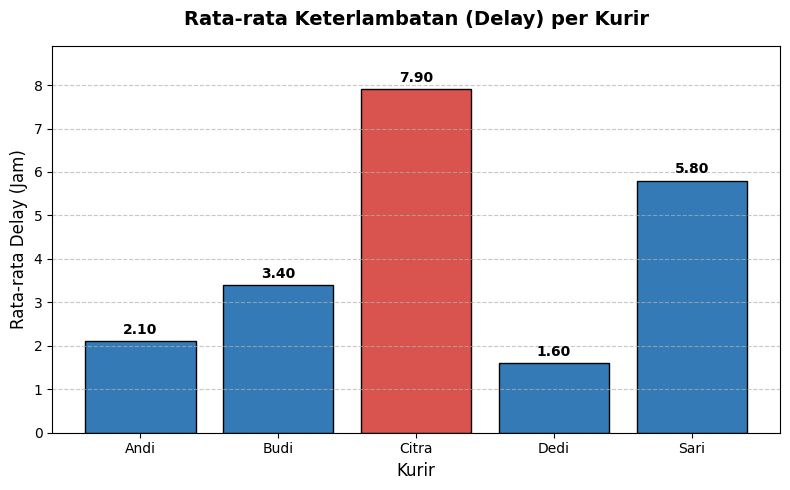

Analisis Korelasi:
Korelasi Jarak (distance_km) dan Delay  : 0.7101
Korelasi Berat (weight_kg) dan Delay    : 0.2198


In [3]:
import matplotlib.pyplot as plt

# Hitung rata-rata delay menggunakan groupby
groupby_avg_delay = df.groupby('courier')['delay_hours'].mean()

# Visualisasi Bar Chart
max_delay_courier = groupby_avg_delay.idxmax()
colors = ['#d9534f' if courier == max_delay_courier else '#337ab7' for courier in groupby_avg_delay.index]

plt.figure(figsize=(8, 5))
bars = plt.bar(groupby_avg_delay.index, groupby_avg_delay.values, color=colors, edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, f"{yval:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Rata-rata Keterlambatan (Delay) per Kurir', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kurir', fontsize=12)
plt.ylabel('Rata-rata Delay (Jam)', fontsize=12)
plt.ylim(0, max(groupby_avg_delay.values) + 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Hitung korelasi Pearson
corr_distance = df['distance_km'].corr(df['delay_hours'])
corr_weight = df['weight_kg'].corr(df['delay_hours'])

print("Analisis Korelasi:")
print(f"Korelasi Jarak (distance_km) dan Delay  : {corr_distance:.4f}")
print(f"Korelasi Berat (weight_kg) dan Delay    : {corr_weight:.4f}")
